# Predicting heart disease using the Machine Learning

This Notebook looks into using the  various Python-based Machine Learning and Data science libreries in an attempt to build a mchine leaning model capable of redicting whether the patient has the heart disease or not based on their medicl attributes

We're going to take the following approach :
1. Problem Defination
2. Data Gathering
3. Evaluation
4. Modelling
5. Experimenting

## 1. Problem Defination
In a statement,
> Given clinical parameters about a patient can we predict whether the patient have the heart disease or not.

## 2. Data
The original came from the cleavland data from the [UCI Machine Repository](https://archive.ics.uci.edu/dataset/45/heart+disease).

**Note** These version is also available on the [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

## 3. Evaluation
> if we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we will pursue the project as it is critical project.

## 4. Features

* age (Age of the patient in years)
* sex (Male/Female)
* cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* chol (serum cholesterol in mg/dl)
* fbs (if fasting blood sugar > 120 mg/dl)
* restecg (resting electrocardiographic results) -- Values: [normal, stt abnormality, lv hypertrophy]
* thalach: maximum heart rate achieved
* exang: exercise-induced angina (True/ False)
* oldpeak: ST depression induced by exercise relative to rest
* slope: the slope of the peak exercise ST segment
* ca: number of major vessels (0-3) colored by fluoroscopy
* thal: [normal; fixed defect; reversible defect]
* target (1 for `having heart disease` 0 for `not having heart disease`)

In [36]:
# loading the improtant utitlity
from utility import model_utility


# importing the library 
import pandas as pd 
import numpy as np 
from scipy.stats import randint

import matplotlib.pyplot as plt
import seaborn as sns

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# scikit learn Model's
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, RocCurveDisplay

In [2]:
# let's load the data-set 
df = pd.read_csv('../data/heart-disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Spliting the data 


In [3]:
X, y = df.drop('target', axis=1), df['target']

In [4]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [5]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [6]:
# splitting into train-test set 
# training set - 80% and the rest 20% is for the testing set 
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                   test_size=0.2) # 0.2 represent the 20% set will be passed to the test set of the data 

In [7]:
type(X_train)

pandas.DataFrame

In [8]:
len(X_train), len(X_test)

(242, 61)

## 1. Modeling 
> Now, we got the data splitted, so now let's `train the model in the training set of the data` and `evaluate the model in the testing set of the data`

## Which estimator we choose to train the model
![Sklearn model Map](../images/modelling/ml_map.svg)

based on the [Sklearn Choosing the Right estimator docs](https://scikit-learn.org/stable/machine_learning_map.html) we are gonna try 3 different `ML estimators`

1. [Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)
2. [RanddomForestClassifier an ensembel model](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
3. [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)



In [9]:
# put the model in a dictionary 
models = {'Logistic Regression' : LogisticRegression(),
         'KNN' : KNeighborsClassifier(),
         'Random Forest' : RandomForestClassifier()}

# let's try the model and evaluate their score 
different_model_score = model_utility.fit_and_score(models=models,
                           X_train=X_train,
                           y_train=y_train,
                           X_test=X_test,
                           y_test=y_test)

C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
different_model_score

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## 2. Model Comparision


In [11]:
model_compares = pd.DataFrame(different_model_score, index=["accuracy"])

In [12]:
model_compares

,Logistic Regression,KNN,Random Forest
accuracy,0.885246,0.688525,0.836066


In [13]:
model_compares.T

,accuracy
Logistic Regression,0.885246
KNN,0.688525
Random Forest,0.836066


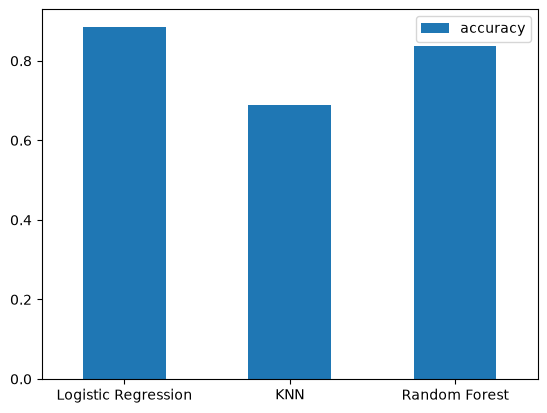

In [14]:
# prepare the plot
ax = model_compares.T.plot(kind='bar');
plt.xticks(rotation=0)
plt.savefig("../images/modelling/001_different_modell_score.png");

## Evaluating the model 
* Nowwe got the basline model's score/accuracy, but as we kno these are the baseline model's.
* I decided to continue with the `LogisticRegression` as it got the **0.885246**


## 3.1 Hyperparameter Tunning 

## 3.1 KNN model

In [15]:
train_score = []
test_score = []

# create the list of the different values for n in K
neighbours = range(1, 21)

# set up KNN instance.
knn = KNeighborsClassifier()

# loop throiugh each neibours 
for i in neighbours:
    # set the parameter of the nneighbours
    knn.set_params(n_neighbors=i)

    # fit the training data 
    knn.fit(X_train, y_train)

    # update the test score list 
    train_score.append(knn.score(X_train, y_train))

    # update the test score list 
    test_score.append(knn.score(X_test, y_test))

    

In [16]:
train_score

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [17]:
test_score

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Maximum Test score achieved is : 75.41


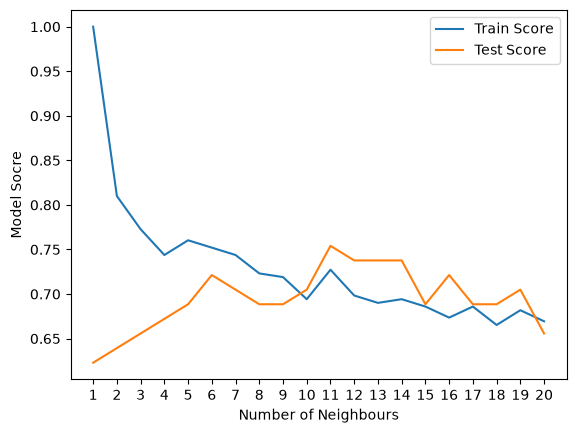

In [18]:
# plot it for better visualization.
plt.plot(neighbours, train_score, label="Train Score")
plt.plot(neighbours, test_score, label="Test Score")
plt.xticks(neighbours)
plt.xlabel("Number of Neighbours")
plt.ylabel("Model Socre")
plt.legend()

print(f"Maximum Test score achieved is : {max(test_score)*100:.2f}")

# save the plot of the score 
plt.savefig("../images/modelling/002_knn_model_tunning.png")

## 3.2 Random Forest 

In [19]:
# let's create the grid for the random forest 

max_dept = [int(x) for x in np.linspace(10, 110, 11)]
max_dept.append(None)
random_forest_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : max_dept,
    'max_features': [ 'sqrt', 'log2', None, 0.2, 0.4, 0.6, 0.8 ],
    'min_samples_split' : randint(2, 50),
    'bootstrap' : [True, False],
    'min_samples_leaf' : np.arange(1, 20)
}

# instantiate the randomforest 
rf_clf = RandomForestClassifier(random_state=42)

# initialize the RandomizedSearchcv 
rf_clf_rd = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=random_forest_grid,
    verbose=3,
    random_state=32
)

# fit the data to the randomizedgrid 
rf_clf_rd.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END bootstrap=False, max_depth=None, max_features=0.6, min_samples_leaf=8, min_samples_split=27, n_estimators=200;, score=0.796 total time=   0.5s
[CV 2/5] END bootstrap=False, max_depth=None, max_features=0.6, min_samples_leaf=8, min_samples_split=27, n_estimators=200;, score=0.837 total time=   0.5s
[CV 3/5] END bootstrap=False, max_depth=None, max_features=0.6, min_samples_leaf=8, min_samples_split=27, n_estimators=200;, score=0.792 total time=   0.5s
[CV 4/5] END bootstrap=False, max_depth=None, max_features=0.6, min_samples_leaf=8, min_samples_split=27, n_estimators=200;, score=0.792 total time=   0.4s
[CV 5/5] END bootstrap=False, max_depth=None, max_features=0.6, min_samples_leaf=8, min_samples_split=27, n_estimators=200;, score=0.771 total time=   0.5s
[CV 1/5] END bootstrap=True, max_depth=100, max_features=0.4, min_samples_leaf=12, min_samples_split=19, n_estimators=200;, score=0.776 total time=   0.6s
[CV 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': array([ 1, 2... 18, 19]), ...}"
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",32
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` 

In [20]:
rf_clf_rd.score(X_test, y_test)

0.8688524590163934

In [21]:
rf_clf_rd.score(X_train, y_train)

0.871900826446281

## 3.3 LogisticRegressor 

In [22]:
different_model_score

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

In [23]:
df.shape

(303, 14)

In [24]:
303 / (14 * np.bincount(y))

array([0.1568323 , 0.13116883])

In [25]:
# preparing the parameter grid 
param_distribution = {
    'solver' : ['liblinear'],
    'C' : np.logspace(-4, 4, num=50),
    'penalty' : ['l1', 'l2'],
    'max_iter' : [1000, 5000, 10000]
}
# convert the data to standardScalar
scalar = StandardScaler()

# transform the X data 
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)

# initialize the RandomSearchCv
rs_log_clf = RandomizedSearchCV(
    estimator=LogisticRegression(),
    verbose=3,
    param_distributions=param_distribution
)

# fit the data to the model 
rs_log_clf.fit(X_train_scaled, y_train)



Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END C=109.85411419875572, max_iter=1000, penalty=l2, solver=liblinear;, score=0.776 total time=   0.0s


C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\minic

[CV 2/5] END C=109.85411419875572, max_iter=1000, penalty=l2, solver=liblinear;, score=0.918 total time=   0.0s
[CV 3/5] END C=109.85411419875572, max_iter=1000, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 4/5] END C=109.85411419875572, max_iter=1000, penalty=l2, solver=liblinear;, score=0.833 total time=   0.0s
[CV 5/5] END C=109.85411419875572, max_iter=1000, penalty=l2, solver=liblinear;, score=0.792 total time=   0.0s
[CV 1/5] END C=0.0013894954943731374, max_iter=1000, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 2/5] END C=0.0013894954943731374, max_iter=1000, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 3/5] END C=0.0013894954943731374, max_iter=1000, penalty=l1, solver=liblinear;, score=0.438 total time=   0.0s
[CV 4/5] END C=0.0013894954943731374, max_iter=1000, penalty=l1, solver=liblinear;, score=0.458 total time=   0.0s
[CV 5/5] END C=0.0013894954943731374, max_iter=1000, penalty=l1, solver=liblinear;, score=0.

C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\minic

[CV 2/5] END C=0.05963623316594643, max_iter=5000, penalty=l2, solver=liblinear;, score=0.878 total time=   0.0s
[CV 3/5] END C=0.05963623316594643, max_iter=5000, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 4/5] END C=0.05963623316594643, max_iter=5000, penalty=l2, solver=liblinear;, score=0.854 total time=   0.0s


C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\minic

[CV 5/5] END C=0.05963623316594643, max_iter=5000, penalty=l2, solver=liblinear;, score=0.750 total time=   0.0s
[CV 1/5] END C=0.0029470517025518097, max_iter=5000, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 2/5] END C=0.0029470517025518097, max_iter=5000, penalty=l1, solver=liblinear;, score=0.449 total time=   0.0s
[CV 3/5] END C=0.0029470517025518097, max_iter=5000, penalty=l1, solver=liblinear;, score=0.438 total time=   0.0s
[CV 4/5] END C=0.0029470517025518097, max_iter=5000, penalty=l1, solver=liblinear;, score=0.458 total time=   0.0s
[CV 5/5] END C=0.0029470517025518097, max_iter=5000, penalty=l1, solver=liblinear;, score=0.458 total time=   0.0s
[CV 1/5] END C=10000.0, max_iter=5000, penalty=l1, solver=liblinear;, score=0.776 total time=   0.0s
[CV 2/5] END C=10000.0, max_iter=5000, penalty=l1, solver=liblinear;, score=0.918 total time=   0.0s
[CV 3/5] END C=10000.0, max_iter=5000, penalty=l1, solver=liblinear;, score=0.771 total time=   0.0s
[CV 4/5] 

C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' 

[CV 4/5] END C=0.0029470517025518097, max_iter=5000, penalty=l2, solver=liblinear;, score=0.875 total time=   0.0s
[CV 5/5] END C=0.0029470517025518097, max_iter=5000, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 1/5] END C=494.1713361323828, max_iter=1000, penalty=l2, solver=liblinear;, score=0.776 total time=   0.0s


C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\minic

[CV 2/5] END C=494.1713361323828, max_iter=1000, penalty=l2, solver=liblinear;, score=0.918 total time=   0.0s
[CV 3/5] END C=494.1713361323828, max_iter=1000, penalty=l2, solver=liblinear;, score=0.771 total time=   0.0s
[CV 4/5] END C=494.1713361323828, max_iter=1000, penalty=l2, solver=liblinear;, score=0.833 total time=   0.0s
[CV 5/5] END C=494.1713361323828, max_iter=1000, penalty=l2, solver=liblinear;, score=0.792 total time=   0.0s
[CV 1/5] END C=0.18420699693267145, max_iter=10000, penalty=l1, solver=liblinear;, score=0.755 total time=   0.0s
[CV 2/5] END C=0.18420699693267145, max_iter=10000, penalty=l1, solver=liblinear;, score=0.837 total time=   0.0s
[CV 3/5] END C=0.18420699693267145, max_iter=10000, penalty=l1, solver=liblinear;, score=0.812 total time=   0.0s
[CV 4/5] END C=0.18420699693267145, max_iter=10000, penalty=l1, solver=liblinear;, score=0.833 total time=   0.0s
[CV 5/5] END C=0.18420699693267145, max_iter=10000, penalty=l1, solver=liblinear;, score=0.750 total

C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\furqa\minic

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'max_iter': [1000, 5000, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a 

In [26]:
rs_log_clf.score(X_test_scaled, y_test)

0.8852459016393442

In [27]:
different_model_score

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

In [28]:
rs_log_clf.best_params_

{'solver': 'liblinear',
 'penalty': 'l2',
 'max_iter': 1000,
 'C': np.float64(109.85411419875572)}

### 4. evaluating our tunned ML classifier, beyond the accuracy:
* ROC and AUC score
* confusion matrix
* classification report
* Precession
* Recall
* f1-score


In [29]:
# let's make the prediction with the tunned model 
y_preds = rs_log_clf.predict(X_test_scaled)
y_pred_probs = rs_log_clf.predict_proba(X_test_scaled)

In [30]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [31]:
y_true = y_test

## 4.1 ROC and AUC curve 
> It is a way of understading how our model is performing well by putting the X (refered as the feature) and y (as the class or a value to predict) work y adjusting the differenct thresholds

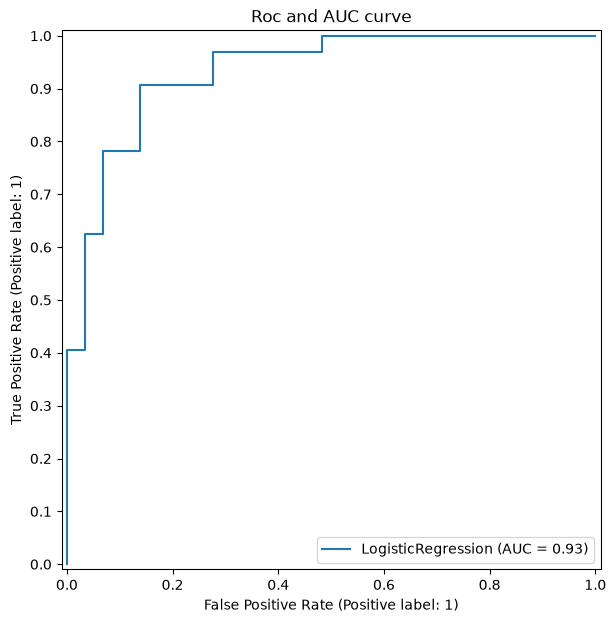

In [32]:
_, ax=plt.subplots(figsize=(10, 7))
# Plot the curve and evaluate the AUC metrix
RocCurveDisplay.from_estimator(
    estimator=rs_log_clf,
    X=X_test_scaled,
    y=y_test,
    name="LogisticRegression",
    ax=ax
)

plt.title('Roc and AUC curve')
plt.yticks(ticks=[0.0, 0.1,0.2, 0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
plt.savefig('../images/evaluation/001_ROC_AUC_CURVE.png')

In [33]:
y_true

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

## 4.2 Confusion matrix Anatonomy
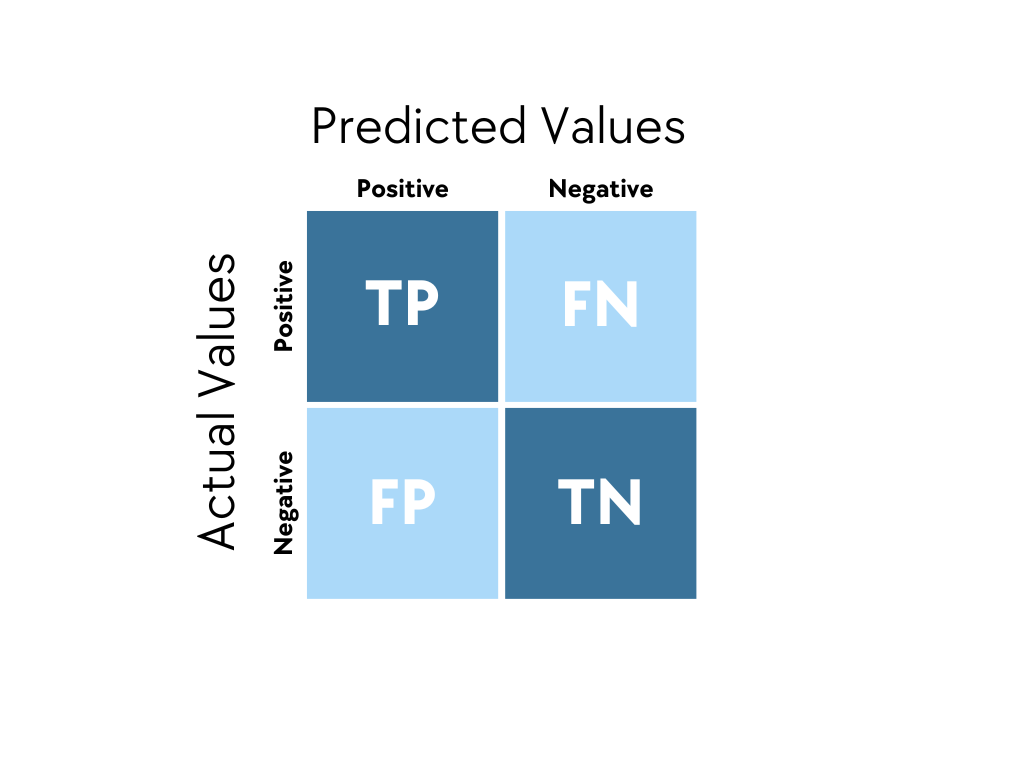

### Terms used in these 
1. TP - Actual is True and the predicted is also true
2. FN - actual is true but the predicted is false
3. FP - Actual is False and predicted is also false
4. TN - actual is False predicted is True

### TPR and FPR 
1. **TPR True Poitive Rate** is something that how much from the data it can discover as the positive.
2. **fpr False Positive Rate** is something that how much from the data it can discover the Negative values 

In [35]:
# create the confusion matrix


In [50]:
# plot the confusion matric using the SNS 
def plot_cnf_mat(y_test, y_preds):
    '''PLot the confsuion matrix using the sns
    Args:
        y_test : Actual Vlaues for the y that will be predicted.
        y_preds : Prediction made by the Model.

    Returns:
        calculate the confusion matix based on the y_true ad the y_preds and plot them in the graph 
    
    '''
    # setting the font size of the confusion_matrix
    sns.set(font_scale=1.5)
    
    # prepare for the confusion matrix 
    cnf_matrics = confusion_matrix(
        y_true=y_true,
        y_pred=y_preds
    )
    
    # initialize the sns heat map 
    heatmap = sns.heatmap(
       data=cnf_matrics,
        annot=True,
        linewidths=0.5,
        cbar=False
    )

    # styling the labels of the HeatMap 
    heatmap.set(xlabel="Predicted Values", ylabel="Actual Values", title="Confusion Matrics")

    # save the plot 
    plt.savefig('../images/evaluation/002_CNF_MATRIX.png')

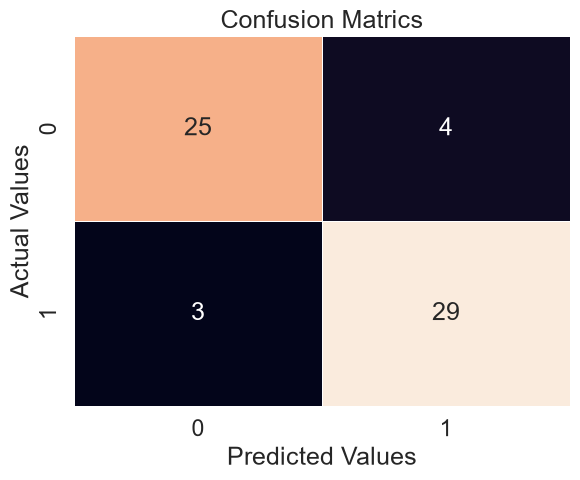

In [51]:
plot_cnf_mat(y_test, y_preds)

In [52]:
TPR = 25 / 25 + 4
FPR = 3 / 3 + 29

In [53]:
TPR 

5.0

In [54]:
FPR

30.0

In [55]:
tpr

NameError: name 'tpr' is not defined

In [57]:
fpr, tpr, threshold = roc_curve(
    y_true,
    y_score=y_pred_probs[:,1]
)

In [58]:
fpr.mean()

np.float64(0.21428571428571427)

In [60]:
threshold[threshold == 0.5 ]

array([], dtype=float64)

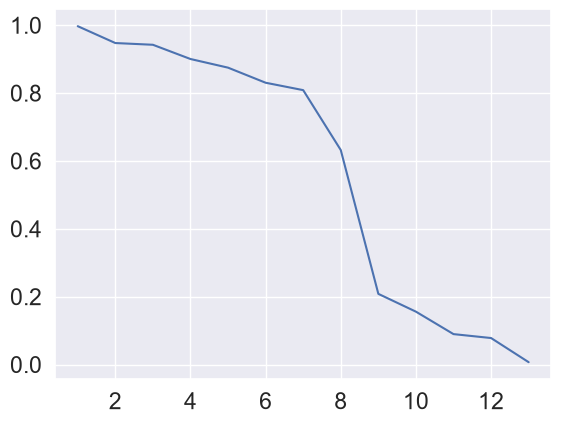

In [62]:
plt.plot(threshold)